#  Modeling of Flight Delay Propagation

The follow jupyter notebook contains data analysis of how flight delays propagate through individual aircrafts daily routes. The goal of this notebook is to impliment a markov chain and calculate its transition matrix to understand how flights switch through states related to their on-time status. This project uses the [BTS Marketing Carrier On-Time Peformance](https://www.transtats.bts.gov/tables.asp?QO_VQ=EFD&QO_anzr=Nv4yv0r) database for analysis. The dataset is downloaded for the month of July 2025, and contains the following columns:
* DAY_OF_WEEK(int) - A number associted to the day of the week the flight took place
* FL_DATE(String) - The date of the flight in d/m/yyyy 12:00:00 AM format
* OP_CARRIER_AIRLINE_ID(int) - A DOT assigned code for the operating airline
* TAIL_NUM(String) - The tail number of the aircraft
* OP_CARRIER_FL_NUM(int) - The flight number used by the operating airline
* ORIGIN(String) - The IATA airport code for the airport of origin
* ORIGIN_CITY_NAME(String) - The city of origin
* DEST(String) - The IATA airport code for the destination airport
* DEST_CITY_NAME(String) - The city of destination
* CRS_DEP_TIME(int) - The planned time of departure (local time hhmm)
* DEP_TIME(float64) - The actual time of departure (local time hhmm)
* DEP_DELAY(float64) - The departure delay in minutes. negative minutes indicating an early departure
* CRS_ARR_TIME(int) - The planned time of arrival (local time hhmm)
* ARR_TIME(float64) - The actual time of arrival (local time hhmm)
* ARR_DELAY(float64) - The arrival delay in minutes. negative minutes indicating an early arrival
* CANCELLED(float64) - 1 if the flight was cancelled
* DIVERTED(float64) - 1 if the flight was diverted
* DUP(String) - Indicates a swapped flight record
* CRS_ELAPSED_TIME(float64) - The planned flight time in minutes
* ACTUAL_ELAPSED_TIME(float64) - The actual flight time in minutes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import airportsdata

In [2]:
#import data
delay_df = pd.read_csv('data/flight_delays.csv')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME
0,1,7/7/2025 12:00:00 AM,19393,N1801U,2677,12191,HOU,"Houston, TX",LAX,"Los Angeles, CA",...,508.0,3.0,630,622.0,-8.0,0.0,0.0,N,205.0,194.0
1,1,7/7/2025 12:00:00 AM,19393,N1801U,964,10994,CHS,"Charleston, SC",AUS,"Austin, TX",...,2227.0,297.0,1915,2.0,287.0,0.0,0.0,N,165.0,155.0
2,1,7/7/2025 12:00:00 AM,19393,N1801U,971,10693,BNA,"Nashville, TN",CHS,"Charleston, SC",...,1925.0,315.0,1640,2148.0,308.0,0.0,0.0,N,90.0,83.0
3,1,7/7/2025 12:00:00 AM,19393,N1801U,971,12892,LAX,"Los Angeles, CA",BNA,"Nashville, TN",...,724.0,14.0,1325,1828.0,NaN,0.0,1.0,N,255.0,NaN
4,1,7/7/2025 12:00:00 AM,19393,N1802U,1037,13204,MCO,"Orlando, FL",IND,"Indianapolis, IN",...,2229.0,69.0,2350,40.0,50.0,0.0,0.0,N,150.0,131.0


## Data Missingness Analysis

In [3]:
delay_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 696049 entries, 0 to 696048
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   DAY_OF_WEEK            696049 non-null  int64  
 1   FL_DATE                696049 non-null  str    
 2   OP_CARRIER_AIRLINE_ID  696049 non-null  int64  
 3   TAIL_NUM               693619 non-null  str    
 4   OP_CARRIER_FL_NUM      696049 non-null  int64  
 5   ORIGIN_AIRPORT_ID      696049 non-null  int64  
 6   ORIGIN                 696049 non-null  str    
 7   ORIGIN_CITY_NAME       696049 non-null  str    
 8   DEST                   696049 non-null  str    
 9   DEST_CITY_NAME         696049 non-null  str    
 10  CRS_DEP_TIME           696049 non-null  int64  
 11  DEP_TIME               679234 non-null  float64
 12  DEP_DELAY              679172 non-null  float64
 13  CRS_ARR_TIME           696049 non-null  int64  
 14  ARR_TIME               677870 non-null  float64

In [4]:
delay_df.isnull().sum()

DAY_OF_WEEK                  0
FL_DATE                      0
OP_CARRIER_AIRLINE_ID        0
TAIL_NUM                  2430
OP_CARRIER_FL_NUM            0
ORIGIN_AIRPORT_ID            0
ORIGIN                       0
ORIGIN_CITY_NAME             0
DEST                         0
DEST_CITY_NAME               0
CRS_DEP_TIME                 0
DEP_TIME                 16815
DEP_DELAY                16877
CRS_ARR_TIME                 0
ARR_TIME                 18179
ARR_DELAY                21308
CANCELLED                    0
DIVERTED                     0
DUP                          0
CRS_ELAPSED_TIME             0
ACTUAL_ELAPSED_TIME      21308
dtype: int64

In [5]:
# view flights with null tail numbers
delay_df[ delay_df['TAIL_NUM'].isnull() ].sample(5)

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME
507185,5,7/25/2025 12:00:00 AM,19977,NaN,1528,12266,IAH,"Houston, TX",MCO,"Orlando, FL",...,NaN,NaN,2327,NaN,NaN,1.0,0.0,N,149.0,NaN
471623,5,7/11/2025 12:00:00 AM,20500,NaN,4439,11267,DAY,"Dayton, OH",ORD,"Chicago, IL",...,NaN,NaN,1428,NaN,NaN,1.0,0.0,N,88.0,NaN
105213,2,7/1/2025 12:00:00 AM,19977,NaN,2235,13495,MSY,"New Orleans, LA",EWR,"Newark, NJ",...,NaN,NaN,2259,NaN,NaN,1.0,0.0,N,184.0,NaN
637442,7,7/13/2025 12:00:00 AM,19977,NaN,1871,14771,SFO,"San Francisco, CA",MCO,"Orlando, FL",...,NaN,NaN,551,NaN,NaN,1.0,0.0,N,326.0,NaN
35386,1,7/14/2025 12:00:00 AM,19977,NaN,1517,11298,DFW,"Dallas/Fort Worth, TX",EWR,"Newark, NJ",...,NaN,NaN,2151,NaN,NaN,1.0,0.0,N,211.0,NaN


It appears that flights with null tail numbers are due to being canceled.

In [6]:
#count of cancelled flights
delay_df.CANCELLED.value_counts()

CANCELLED
0.0    678101
1.0     17948
Name: count, dtype: int64

In [7]:
#count of duplicate flights
delay_df.DUP.value_counts()

DUP
N    696049
Name: count, dtype: int64

In [8]:
#count of diverted flights
delay_df.DIVERTED.value_counts()

DIVERTED
0.0    692689
1.0      3360
Name: count, dtype: int64

In [9]:
#count nulls among non-cancelled flights
delay_df[delay_df.CANCELLED == 0].isnull().sum()

DAY_OF_WEEK                 0
FL_DATE                     0
OP_CARRIER_AIRLINE_ID       0
TAIL_NUM                    0
OP_CARRIER_FL_NUM           0
ORIGIN_AIRPORT_ID           0
ORIGIN                      0
ORIGIN_CITY_NAME            0
DEST                        0
DEST_CITY_NAME              0
CRS_DEP_TIME                0
DEP_TIME                    0
DEP_DELAY                   0
CRS_ARR_TIME                0
ARR_TIME                  231
ARR_DELAY                3360
CANCELLED                   0
DIVERTED                    0
DUP                         0
CRS_ELAPSED_TIME            0
ACTUAL_ELAPSED_TIME      3360
dtype: int64

In [10]:
#count nulls among non-cancelled and non-diverted flights
delay_df[(delay_df.CANCELLED == 0) & (delay_df.DIVERTED == 0)].isnull().sum()

DAY_OF_WEEK              0
FL_DATE                  0
OP_CARRIER_AIRLINE_ID    0
TAIL_NUM                 0
OP_CARRIER_FL_NUM        0
ORIGIN_AIRPORT_ID        0
ORIGIN                   0
ORIGIN_CITY_NAME         0
DEST                     0
DEST_CITY_NAME           0
CRS_DEP_TIME             0
DEP_TIME                 0
DEP_DELAY                0
CRS_ARR_TIME             0
ARR_TIME                 0
ARR_DELAY                0
CANCELLED                0
DIVERTED                 0
DUP                      0
CRS_ELAPSED_TIME         0
ACTUAL_ELAPSED_TIME      0
dtype: int64

We can see that most null values are attributed to the flight being cancelled with the exception of arrival time and arrival delay. According to the BTS metadata, flights that were diverted end up having null arrival times. If we observe non-cancelled and non-diverted flights, we can see that there is no data missing. All null values can be attributed to cancelled and diverted flights in this dataset. We can drop null tail numbers, since tail numbers are crucial to assigning flights to chains.

In [11]:
delay_df = delay_df.dropna(subset="TAIL_NUM")

## Time handling
We must handle times columns prior to creating the Markov chain. These columns are currently strings and ints rather than proper datetime objects and need cleaning. FL_DATE is a string, and arrival and depature times are numeric rather than timestamps. These values are all in local time as well. We will need to be able to compare flights across timezones.The current FL_DATE only accounts for the scheduled departure time, but not cases where flights are delayed to the next day.

In [12]:
#convert FL_DATE to datetime
delay_df['FL_DATE'] = pd.to_datetime(delay_df['FL_DATE'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

In [13]:
#Format local CRS departure time 

#pad to 4 digits
delay_df['CRS_DEP_LT'] = pd.to_numeric(delay_df['CRS_DEP_TIME'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(4)

#replace flights at midnight with 2359 for dt handling
delay_df['CRS_DEP_LT'] = delay_df['CRS_DEP_LT'].replace('2400', '2359')

#convert to datetime
delay_df['CRS_DEP_LT'] = pd.to_datetime(delay_df['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + delay_df['CRS_DEP_LT'].str[:2] + ':' + delay_df['CRS_DEP_LT'].str[2:], format='%Y-%m-%d %H:%M', errors='coerce')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT
0,1,2025-07-07,19393,N1801U,2677,12191,HOU,"Houston, TX",LAX,"Los Angeles, CA",...,3.0,630,622.0,-8.0,0.0,0.0,N,205.0,194.0,2025-07-07 05:05:00
1,1,2025-07-07,19393,N1801U,964,10994,CHS,"Charleston, SC",AUS,"Austin, TX",...,297.0,1915,2.0,287.0,0.0,0.0,N,165.0,155.0,2025-07-07 17:30:00
2,1,2025-07-07,19393,N1801U,971,10693,BNA,"Nashville, TN",CHS,"Charleston, SC",...,315.0,1640,2148.0,308.0,0.0,0.0,N,90.0,83.0,2025-07-07 14:10:00
3,1,2025-07-07,19393,N1801U,971,12892,LAX,"Los Angeles, CA",BNA,"Nashville, TN",...,14.0,1325,1828.0,NaN,0.0,1.0,N,255.0,NaN,2025-07-07 07:10:00
4,1,2025-07-07,19393,N1802U,1037,13204,MCO,"Orlando, FL",IND,"Indianapolis, IN",...,69.0,2350,40.0,50.0,0.0,0.0,N,150.0,131.0,2025-07-07 21:20:00


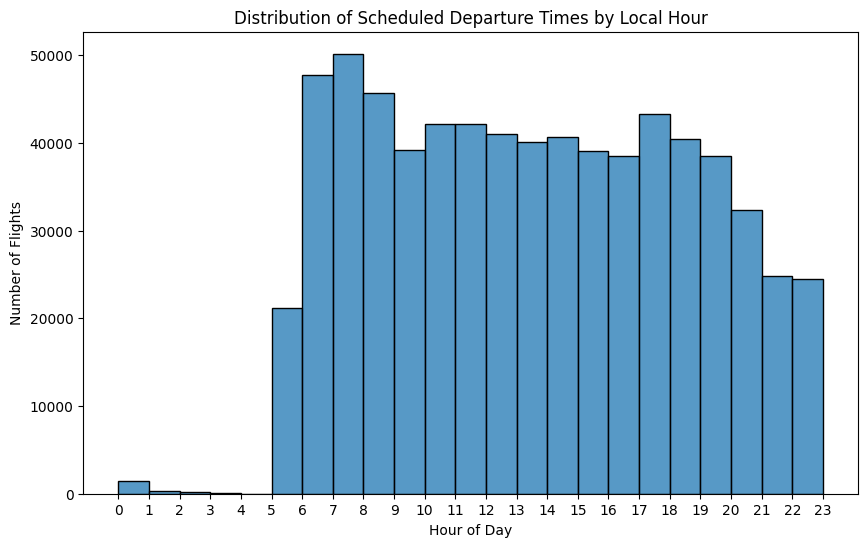

In [14]:
# plot distribution of departure times by the hour
plt.figure(figsize=(10,6))
sns.histplot(delay_df['CRS_DEP_LT'].dt.hour, bins=23, kde=False)
plt.title('Distribution of Scheduled Departure Times by Local Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.xticks(range(0,24))
plt.show()
plt.close()

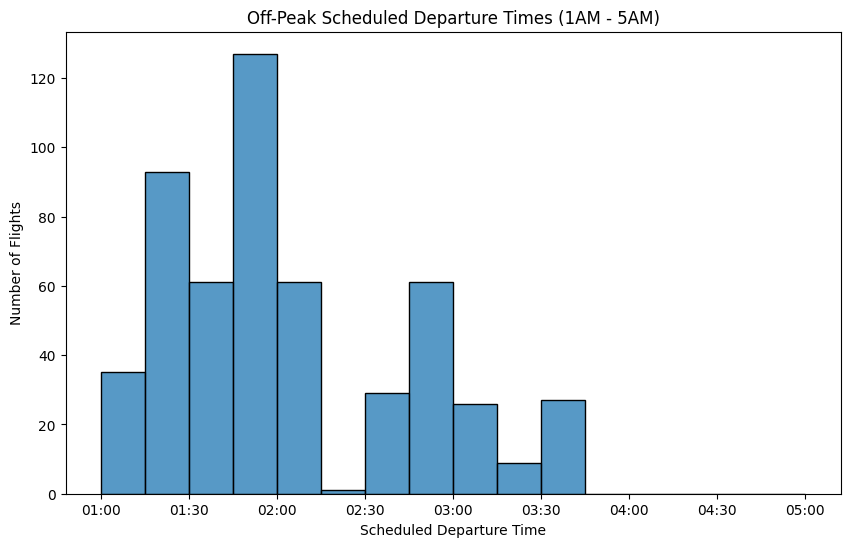

In [15]:
# plot off-peak departure in 15 minute intervals (1am-4am)
off_hour_flights = delay_df[ (delay_df['CRS_DEP_LT'].dt.hour < 5) & (delay_df['CRS_DEP_LT'].dt.hour >= 1) ]

off_hour_flights['minutes_of_day'] = (off_hour_flights['CRS_DEP_LT'].dt.hour * 60 + off_hour_flights['CRS_DEP_LT'].dt.minute)

plt.figure(figsize=(10,6))
sns.histplot(
    data=off_hour_flights, 
    x='minutes_of_day', 
    bins=range(60, 315, 15),
    kde=False
)

ticks = range(60, 315, 30)
labels = [f"{m//60:02d}:{m%60:02d}" for m in ticks]
plt.xticks(ticks, labels)

plt.title('Off-Peak Scheduled Departure Times (1AM - 5AM)')
plt.xlabel('Scheduled Departure Time')
plt.ylabel('Number of Flights')
plt.show()
plt.close()

#cleanup
del off_hour_flights

From these plots we can observe that a vast majority of flights are scheduled to depart between 5 AM and 12 AM. Scheduled departures fall off significantly after midnight and no flights were scheduled between 3:45 AM and 5 AM. With this information we can classify an aircraft's operating schedule to be between 5 AM and 3:45 AM the following day.

In [16]:
delay_df['Operational_Date'] = (delay_df['CRS_DEP_LT'] - pd.Timedelta(hours=5)).dt.date

In [17]:
# Calculate universal departure time
airports = airportsdata.load('IATA')
delay_df['CRS_DEP_UTC'] = pd.NaT

def get_tz(iata_code):
    return airports[iata_code]['tz']

delay_df['DEP_TZ'] = delay_df['ORIGIN'].apply(get_tz)

#process timezones in groups
for tz, group in delay_df.groupby('DEP_TZ'):
    utc = (group['CRS_DEP_LT'].dt.tz_localize(tz, ambiguous='NaT', nonexistent='NaT').dt.tz_convert('UTC').dt.tz_localize(None))

    delay_df.loc[group.index, 'CRS_DEP_UTC'] = utc

delay_df.loc[group.index, 'CRS_DEP_UTC'] = utc

delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,ARR_DELAY,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ
0,1,2025-07-07,19393,N1801U,2677,12191,HOU,"Houston, TX",LAX,"Los Angeles, CA",...,-8.0,0.0,0.0,N,205.0,194.0,2025-07-07 05:05:00,2025-07-07,2025-07-07 10:05:00,America/Chicago
1,1,2025-07-07,19393,N1801U,964,10994,CHS,"Charleston, SC",AUS,"Austin, TX",...,287.0,0.0,0.0,N,165.0,155.0,2025-07-07 17:30:00,2025-07-07,2025-07-07 21:30:00,America/New_York
2,1,2025-07-07,19393,N1801U,971,10693,BNA,"Nashville, TN",CHS,"Charleston, SC",...,308.0,0.0,0.0,N,90.0,83.0,2025-07-07 14:10:00,2025-07-07,2025-07-07 19:10:00,America/Chicago
3,1,2025-07-07,19393,N1801U,971,12892,LAX,"Los Angeles, CA",BNA,"Nashville, TN",...,NaN,0.0,1.0,N,255.0,NaN,2025-07-07 07:10:00,2025-07-07,2025-07-07 14:10:00,America/Los_Angeles
4,1,2025-07-07,19393,N1802U,1037,13204,MCO,"Orlando, FL",IND,"Indianapolis, IN",...,50.0,0.0,0.0,N,150.0,131.0,2025-07-07 21:20:00,2025-07-07,2025-07-08 01:20:00,America/New_York


In [18]:
# Create actual depature time in local time
delay_df['DEP_TIME_LT'] = delay_df['CRS_DEP_LT'] + pd.to_timedelta(delay_df['DEP_DELAY'], unit='m')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ,DEP_TIME_LT
0,1,2025-07-07,19393,N1801U,2677,12191,HOU,"Houston, TX",LAX,"Los Angeles, CA",...,0.0,0.0,N,205.0,194.0,2025-07-07 05:05:00,2025-07-07,2025-07-07 10:05:00,America/Chicago,2025-07-07 05:08:00
1,1,2025-07-07,19393,N1801U,964,10994,CHS,"Charleston, SC",AUS,"Austin, TX",...,0.0,0.0,N,165.0,155.0,2025-07-07 17:30:00,2025-07-07,2025-07-07 21:30:00,America/New_York,2025-07-07 22:27:00
2,1,2025-07-07,19393,N1801U,971,10693,BNA,"Nashville, TN",CHS,"Charleston, SC",...,0.0,0.0,N,90.0,83.0,2025-07-07 14:10:00,2025-07-07,2025-07-07 19:10:00,America/Chicago,2025-07-07 19:25:00
3,1,2025-07-07,19393,N1801U,971,12892,LAX,"Los Angeles, CA",BNA,"Nashville, TN",...,0.0,1.0,N,255.0,NaN,2025-07-07 07:10:00,2025-07-07,2025-07-07 14:10:00,America/Los_Angeles,2025-07-07 07:24:00
4,1,2025-07-07,19393,N1802U,1037,13204,MCO,"Orlando, FL",IND,"Indianapolis, IN",...,0.0,0.0,N,150.0,131.0,2025-07-07 21:20:00,2025-07-07,2025-07-08 01:20:00,America/New_York,2025-07-07 22:29:00


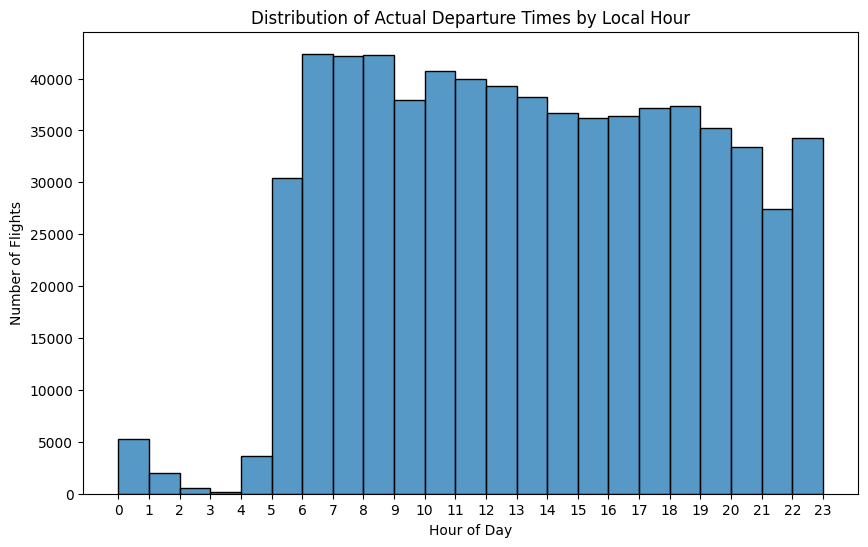

In [19]:
# plot distribution of actual departure times by the localhour
plt.figure(figsize=(10,6))
sns.histplot((delay_df['CRS_DEP_LT'] + pd.to_timedelta(delay_df['DEP_DELAY'], unit='m')).dt.hour, bins=23, kde=False)
plt.title('Distribution of Actual Departure Times by Local Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.xticks(range(0,24))
plt.show()
plt.close()

## Assign states to flights

Next we'll assign states to each flight to later compute the transition matrix. The following states will be assigned to flights

0. On-time: An arrival delay less than 15 minutes
1. Delay: An arrival delay of 15 minutes or more (FAA classification)
2. Extreme Delay: An arrival delay of 60 minutes or more
3. Sequence Failure: An absorbing state for when the chain fails. This state is split into three cases
* A cancelled flight
* A diverted flight
* A rollover delay 

A rollover delay is a delay so extreme that it breaks the chain. Further analysis will be conducted to decide this cutoff.

count    674741.000000
mean         17.251113
std          72.638143
min         -83.000000
25%         -13.000000
50%          -3.000000
75%          20.000000
max        2557.000000
Name: ARR_DELAY, dtype: float64


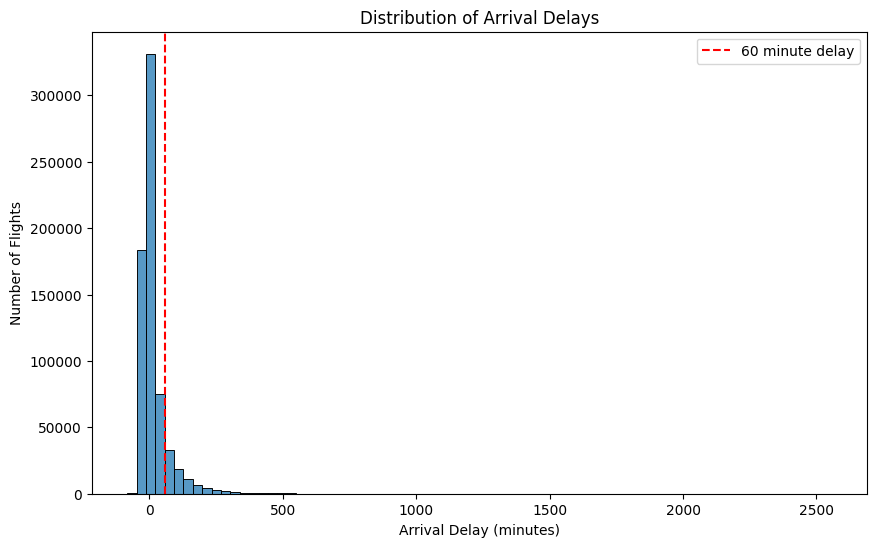

In [20]:
print(delay_df.ARR_DELAY.describe())


# plot distribution of arrival delays
plt.figure(figsize=(10,6))
sns.histplot(delay_df['ARR_DELAY'].dropna(), bins=75, kde=False)
plt.title('Distribution of Arrival Delays')
plt.axvline(60, color='red', linestyle='--', label='60 minute delay')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Number of Flights')
plt.legend()
plt.show()
plt.close()

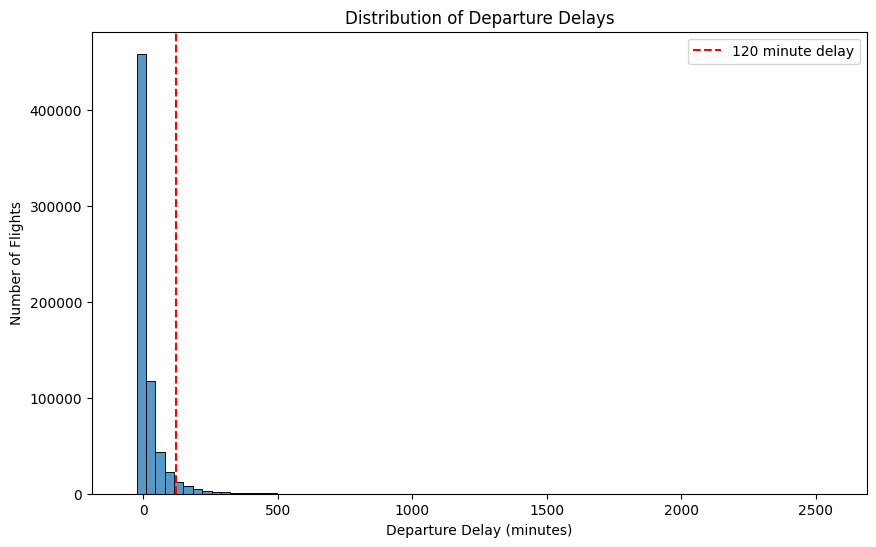

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(delay_df['DEP_DELAY'].dropna(), bins=75, kde=False)
plt.axvline(120, color='red', linestyle='--', label='120 minute delay')
plt.legend()
plt.title('Distribution of Departure Delays')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Number of Flights')
plt.show()
plt.close()

The departure plot shows that a vast majority of flights are on time or slightly delayed. Delay time falls off significantly after 120 minutes. We will use 120 minutes (2 hours) as our cutoff for the rollover delay.

In [22]:
#classify flights as delayed or not 
delay_df['IS_ARR_DELAY'] = delay_df['ARR_DELAY'] >= 15

# set state variable for modeling
delay_df['STATE'] = delay_df['IS_ARR_DELAY'] * 1
extreme_mask = delay_df['ARR_DELAY'] >= 60
delay_df.loc[extreme_mask, 'STATE'] = 2

# define sequence failures
cancelled_mask = delay_df['CANCELLED'] == 1
diverted_mask = delay_df['DIVERTED'] == 1
rollover_mask = delay_df['DEP_DELAY'] >= 120

delay_df.loc[cancelled_mask | diverted_mask | rollover_mask, 'STATE'] = 3
delay_df.STATE.value_counts()


STATE
0    481849
1    111360
3     53663
2     46747
Name: count, dtype: int64

## Assign flights to chains.

Each chain consists of the flights that an individual tail number flew for 24 hour periods starting at 5AM the following day.

In [23]:
# flights to inorder of scheduled departure time in UTC
delay_df = delay_df.sort_values(by=['TAIL_NUM', 'Operational_Date', 'CRS_DEP_UTC', 'STATE'])

# remove cases of ghost flights, a flight was cancelled, but the aircraft was scheduled for another flight at the same time
delay_df = delay_df.drop_duplicates(subset=['TAIL_NUM', 'Operational_Date', 'CRS_DEP_UTC'], keep='first')

# assign an ID to each chain
delay_df['CHAIN_ID'] = delay_df.groupby(['TAIL_NUM', 'Operational_Date']).ngroup()

Number of chains: 162710


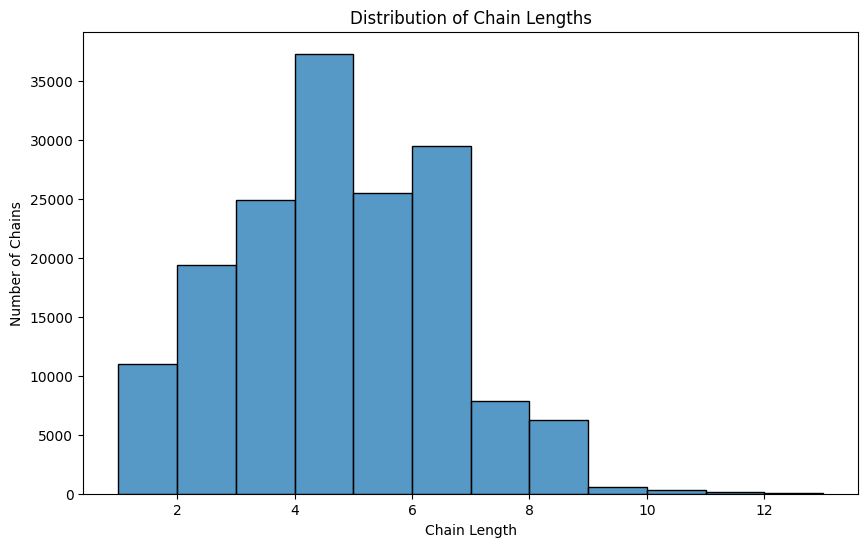

1     10990
2     19396
3     24847
4     37275
5     25513
6     29473
7      7894
8      6257
9       585
10      297
11      142
12       40
13        1
Name: count, dtype: int64


In [24]:
# count the number of chains
print("Number of chains:", delay_df['CHAIN_ID'].nunique())

# plot distribution of chain lengths
chain_lengths = delay_df.groupby('CHAIN_ID').size()
plt.figure(figsize=(10,6))
sns.histplot(chain_lengths, bins=range(1, chain_lengths.max() + 1), kde=False)
plt.title('Distribution of Chain Lengths')
plt.xlabel('Chain Length')
plt.ylabel('Number of Chains')
plt.show()
plt.close()

# count number of chains of each length
chain_length_counts = chain_lengths.value_counts().sort_index()
print(chain_length_counts)

This data shows that most aircrafts take roughly 4 to 6 flights in an operating day, however, many only take 1 or 2. There appears to be some aircrafts that fly many flights in a day. These are presumably aircrafts are take regional flights with shorter flight times.

In [25]:
delay_df[delay_df['CHAIN_ID'] == 12356]

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ,DEP_TIME_LT,IS_ARR_DELAY,STATE,CHAIN_ID
349673,4,2025-07-10,20304,N150SY,4640,12217,HSV,"Huntsville, AL",DEN,"Denver, CO",...,190.0,200.0,2025-07-10 08:09:00,2025-07-10,2025-07-10 13:09:00,America/Chicago,2025-07-10 08:16:00,True,1,12356
349676,4,2025-07-10,20304,N150SY,5506,11292,DEN,"Denver, CO",ACV,"Arcata/Eureka, CA",...,182.0,170.0,2025-07-10 11:29:00,2025-07-10,2025-07-10 17:29:00,America/Denver,2025-07-10 11:33:00,False,0,12356
349674,4,2025-07-10,20304,N150SY,4655,10157,ACV,"Arcata/Eureka, CA",SFO,"San Francisco, CA",...,76.0,61.0,2025-07-10 14:19:00,2025-07-10,2025-07-10 21:19:00,America/Los_Angeles,2025-07-10 14:13:00,False,0,12356
349677,4,2025-07-10,20304,N150SY,5664,14771,SFO,"San Francisco, CA",EUG,"Eugene, OR",...,98.0,84.0,2025-07-10 16:10:00,2025-07-10,2025-07-10 23:10:00,America/Los_Angeles,2025-07-10 16:09:00,False,0,12356
349678,4,2025-07-10,20304,N150SY,5838,11603,EUG,"Eugene, OR",SFO,"San Francisco, CA",...,101.0,84.0,2025-07-10 18:29:00,2025-07-10,2025-07-11 01:29:00,America/Los_Angeles,2025-07-10 18:20:00,False,0,12356
349675,4,2025-07-10,20304,N150SY,4737,14771,SFO,"San Francisco, CA",BFL,"Bakersfield, CA",...,75.0,81.0,2025-07-10 21:30:00,2025-07-10,2025-07-11 04:30:00,America/Los_Angeles,2025-07-10 21:27:00,False,0,12356


In [ ]:
failed_chain_ids = delay_df[delay_df['STATE'] == 3]['CHAIN_ID'].unique()

failed_chains = delay_df[delay_df['CHAIN_ID'].isin(failed_chain_ids)]



array([     0,     16,     29, ..., 162696, 162698, 162709],
      shape=(32036,))

In [42]:
delay_df[delay_df['CHAIN_ID'] == failed_chain_ids[7]][['TAIL_NUM', 'ORIGIN_CITY_NAME', 'DEST_CITY_NAME', 'STATE', 'Operational_Date', 'CRS_DEP_UTC', 'DEP_TIME_LT', 'DEP_DELAY', 'ARR_DELAY', 'CANCELLED']]

,TAIL_NUM,ORIGIN_CITY_NAME,DEST_CITY_NAME,STATE,Operational_Date,CRS_DEP_UTC,DEP_TIME_LT,DEP_DELAY,ARR_DELAY,CANCELLED
554720,190NV,"St. Petersburg, FL","Lexington, KY",0,2025-07-12,2025-07-12 12:10:00,2025-07-12 08:06:00,-4.0,-11.0,0.0
554724,190NV,"Knoxville, TN","St. Petersburg, FL",3,2025-07-12,2025-07-12 12:30:00,2025-07-12 21:53:00,803.0,807.0,0.0
554721,190NV,"Lexington, KY","St. Petersburg, FL",0,2025-07-12,2025-07-12 15:00:00,2025-07-12 10:50:00,-10.0,-15.0,0.0
554725,190NV,"St. Petersburg, FL","Knoxville, TN",3,2025-07-12,2025-07-12 15:01:00,2025-07-12 19:19:00,498.0,509.0,0.0
554723,190NV,"St. Petersburg, FL","Roanoke, VA",0,2025-07-12,2025-07-12 17:46:00,2025-07-12 13:26:00,-20.0,-22.0,0.0
554722,190NV,"Roanoke, VA","St. Petersburg, FL",0,2025-07-12,2025-07-12 20:36:00,2025-07-12 16:16:00,-20.0,-20.0,0.0
